# Exersise 1: Wine dataset

## Get the data

In [1]:
from sklearn.datasets import load_wine

wine_data = load_wine()

In [2]:
import pandas as pd
wine_df = pd.DataFrame(wine_data.data, columns=wine_data.feature_names)
wine_df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [3]:
wine_target = pd.DataFrame(wine_data.target, columns=['target'])
wine_target.describe()

,target
count,178.000000
mean,0.938202
std,0.775035
min,0.000000
25%,0.000000
50%,1.000000
75%,2.000000
max,2.000000


In [4]:
wine_target['target'].unique()

array([0, 1, 2])

In [5]:
print(wine_data.target_names)

['class_0' 'class_1' 'class_2']


In [6]:
wine_df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [16]:
import numpy as np

X = wine_data.data
y = wine_data.target

print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")

Shape of features (X): (178, 13)
Shape of target (y): (178,)


## Split Data

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (142, 13)
Shape of X_test: (36, 13)
Shape of y_train: (142,)
Shape of y_test: (36,)


## Feature Scaling


In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Shape of X_train_scaled: {X_train_scaled.shape}")
print(f"Shape of X_test_scaled: {X_test_scaled.shape}")

Shape of X_train_scaled: (142, 13)
Shape of X_test_scaled: (36, 13)


## Train and Tune SVM
I chose OvR


In [30]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto', 0.1, 0.01, 0.001]
}

svc = SVC(decision_function_shape='ovr')

grid_search = GridSearchCV(svc, param_grid, cv=5, verbose=3, scoring='accuracy', n_jobs=-1)

grid_search.fit(X_train_scaled, y_train)

print("Best parameters found by GridSearchCV:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best parameters found by GridSearchCV: {'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}
Best cross-validation accuracy: 0.9788177339901478


In [31]:
best_svm = grid_search.best_estimator_

print("Best kernel:", best_svm.kernel)
print("Number of features:", X_train_scaled.shape[1])

Best kernel: rbf
Number of features: 13


## Visualize the result

In [32]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)

X_train_pca = pca.fit_transform(X_train_scaled)

X_test_pca = pca.transform(X_test_scaled)

print(f"Shape of X_train_pca: {X_train_pca.shape}")
print(f"Shape of X_test_pca: {X_test_pca.shape}")

Shape of X_train_pca: (142, 2)
Shape of X_test_pca: (36, 2)


In [33]:
from sklearn.svm import SVC

best_params = grid_search.best_params_

svm_pca = SVC(C=best_params['C'], kernel=best_params['kernel'], gamma=best_params['gamma'], random_state=42)

svm_pca.fit(X_train_pca, y_train)

print("2D SVM model (svm_pca) trained successfully using best hyperparameters from GridSearchCV.")

2D SVM model (svm_pca) trained successfully using best hyperparameters from GridSearchCV.


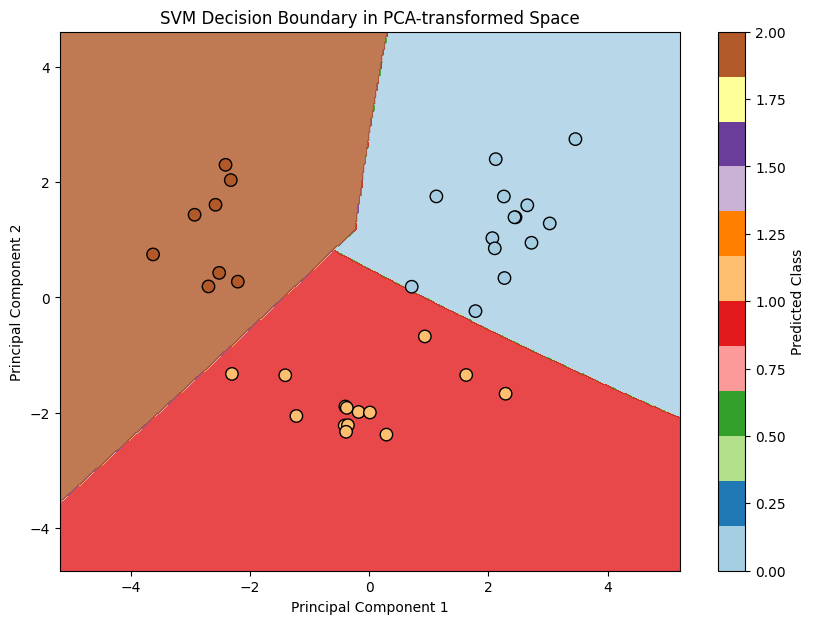

2D Decision Boundary plot generated successfully.


In [34]:
import numpy as np
import matplotlib.pyplot as plt

x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = svm_pca.predict(np.c_[xx.ravel(), yy.ravel()])

Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Paired)
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, cmap=plt.cm.Paired, edgecolors='k', s=80)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('SVM Decision Boundary in PCA-transformed Space')
plt.colorbar(label='Predicted Class')
plt.show()

print("2D Decision Boundary plot generated successfully.")

## Evaluate Model Performance

In [39]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

best_svm = grid_search.best_estimator_
y_pred = best_svm.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

precision = precision_score(y_test, y_pred, average='weighted')
print(f"Precision: {precision:.4f}")

recall = recall_score(y_test, y_pred, average='weighted')
print(f"Recall: {recall:.4f}")
conf_matrix = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])
print("\nConfusion Matrix:")
print(conf_matrix)

Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000

Confusion Matrix:
[[14  0  0]
 [ 0 14  0]
 [ 0  0  8]]


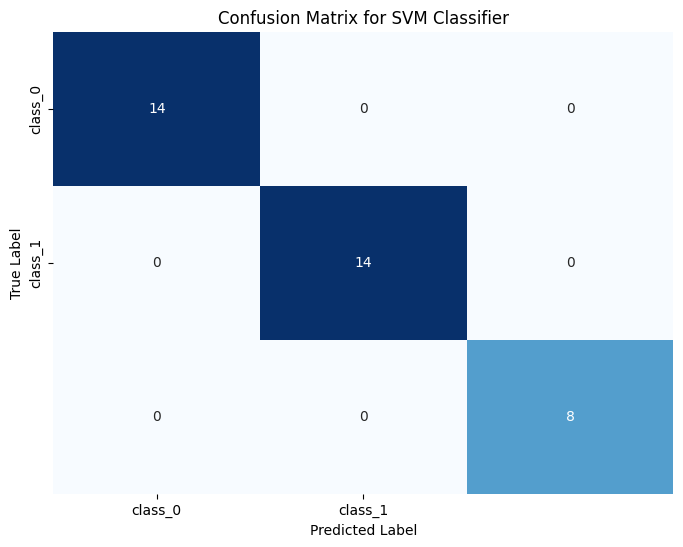

Confusion matrix visualized successfully.


In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=wine_data.target_names, yticklabels=wine_data.target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for SVM Classifier')
plt.show()

print("Confusion matrix visualized successfully.")

## Try to Train and Evaluate SVM without Scaling

In [37]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix


svc_unscaled = SVC(C=grid_search.best_params_['C'],
                   kernel=grid_search.best_params_['kernel'],
                   gamma=grid_search.best_params_['gamma'],
                   random_state=42)

svc_unscaled.fit(X_train, y_train)

y_pred_unscaled = svc_unscaled.predict(X_test)

accuracy_unscaled = accuracy_score(y_test, y_pred_unscaled)
precision_unscaled = precision_score(y_test, y_pred_unscaled, average='weighted')
recall_unscaled = recall_score(y_test, y_pred_unscaled, average='weighted')
conf_matrix_unscaled = confusion_matrix(y_test, y_pred_unscaled, labels=[0, 1, 2])

print(f"SVM Performance without Scaling ")
print(f"Accuracy: {accuracy_unscaled:.4f}")
print(f"Precision: {precision_unscaled:.4f}")
print(f"Recall: {recall_unscaled:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix_unscaled)


SVM Performance without Scaling 
Accuracy: 0.6389
Precision: 0.6980
Recall: 0.6389

Confusion Matrix:
[[ 9  4  1]
 [ 0 11  3]
 [ 0  5  3]]


## Finding:
*  The best hyperparameters (C, kernel, and gamma) previously identified via GridSearchCV were successfully retrieved and used to train the 2D SVM model.
* The scaling improve the accuracy a lot as I can see from the draft 2 (without feature scaling).

* For this multi-class classification problem, the best test metrics to consider Precision, and the Confusion Matrix. While Accuracy (the overall proportion of correct predictions) is also reported and is 100% for the scaled model, it can be misleading in scenarios with highly imbalanced classes. However, in this case, since the weighted precision and recall are also 100%, it consistently indicates perfect classification for the scaled model.

*   The SVM decision boundary was visualized by first applying Principal Component Analysis (PCA) to reduce the scaled training data to two components. A new SVM classifier was then trained using these 2 principal components and the previously optimized hyperparameters. Finally, the decision boundary of this 2D SVM was plotted, with the original scaled test data points transformed into the 2-dimensional PCA space and colored by their true class labels, overlaid on the plot.


# Exersise 2: Housing dataset

## Get the data

In [53]:
from sklearn.datasets import fetch_california_housing

housing_data = fetch_california_housing()

X = housing_data.data[:2000]
y = housing_data.target[:2000]

In [55]:
print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")

Shape of features (X): (2000, 8)
Shape of target (y): (2000,)


## Split Data

In [56]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (1600, 8)
Shape of X_test: (400, 8)
Shape of y_train: (1600,)
Shape of y_test: (400,)


## Feature Scaling


In [57]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Shape of X_train_scaled: {X_train_scaled.shape}")
print(f"Shape of X_test_scaled: {X_test_scaled.shape}")

Shape of X_train_scaled: (1600, 8)
Shape of X_test_scaled: (400, 8)


## Train and Tune SVR


In [58]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto', 0.1, 0.01, 0.001],
    'epsilon': [0.01, 0.1, 0.5, 1]
}

svr = SVR()

grid_search = GridSearchCV(
    svr,
    param_grid,
    cv=5,
    verbose=3,
    scoring='neg_mean_squared_error',  # important for regression
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print("Best parameters found:", grid_search.best_params_)
print("Best CV score (neg MSE):", grid_search.best_score_)

Fitting 5 folds for each of 160 candidates, totalling 800 fits
Best parameters found: {'C': 10, 'epsilon': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV score (neg MSE): -0.20840025610980098


In [59]:
best_svr = grid_search.best_estimator_

print("Best kernel:", best_svr.kernel)
print("Number of features:", X_train_scaled.shape[1])

Best kernel: rbf
Number of features: 8


## Evaluate Model Performance

In [64]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_pred = best_svr.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Regression Evaluation Metrics:")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")

Regression Evaluation Metrics:
MSE:  0.1547
RMSE: 0.3933
MAE:  0.2580
R²:   0.8306


## Finding

* The best metric is R-squared as it is appropriate because this is a regression problem predicting continuous housing prices, and it measures how well the model explains variance in the target variable. However, RMSE is also an essential metric for this type of problem because it tells me the prediction error in the same unit as the target (house value).

* The RBF kernel outperformed the linear kernel, indicating that the relationship between housing features and house prices is nonlinear.

* The model showed moderate sensitivity to both C and gamma, with performance improving when nonlinear flexibility was allowed but decreasing when parameters became too extreme, indicating the need for balanced regularization.

# Reflection & Summary

### 1. What did you learn about SVM?

*  The most striking observation was the critical importance of feature scaling for SVMs. For the Wine dataset, the scaled model achieved perfect classification (100% accuracy), while the unscaled model performed significantly worse (around 64% accuracy). This clearly demonstrated that SVMs, being distance-based algorithms, are highly sensitive to the magnitude of features. Without scaling, features with larger values can dominate the distance calculations, leading to suboptimal or completely erroneous decision boundaries.

*   Hyperparameter tuning via GridSearchCV was essential. The C parameter (regularization) was crucial for balancing misclassification and margin width; too low C would lead to underfitting, while too high C could cause overfitting. For the RBF kernel, gamma dictated the influence of individual training samples (the 'reach' of the kernel), affecting the complexity of the decision boundary. A small gamma indicates a large radius of influence, leading to smoother boundaries, while a large gamma leads to a small radius of influence, creating more complex, potentially overfitting boundaries. In SVR, epsilon defined the margin of tolerance within which no penalty is associated with errors, influencing how many support vectors are selected and the model's robustness to noise.

*   The RBF kernel consistently outperformed the linear kernel in both classification and regression tasks. This indicates that the relationships within both the Wine and Housing datasets were non-linear, and the RBF kernel successfully mapped the data into a higher-dimensional space where linear separation (for classification) or linear regression (for SVR) was possible.

*   While not directly visualized for the full 13-feature model, the principle of maximizing the margin was evident in the perfect separation achieved on the Wine dataset. The decision boundary plot in the PCA-transformed 2D space (though a simplification) showed how the SVM aims to find the widest possible 'street' between classes, defined by the support vectors.

### 2. When might ensemble methods be more beneficial than SVM?

While SVMs are powerful, ensemble methods often offer advantages in several scenarios:

*   For very large datasets, SVMs can become computationally expensive, primarily due to the quadratic programming problem involved in finding the optimal hyperplane. In the housing problem, the SVR from SVM for regression task took around 7' to train and tune for 2000 samples, and it will take forever for the whole housing dataset.

*   Both RBF SVMs and ensemble methods (especially tree-based ones) excel at capturing non-linear relationships. However, for extremely complex or high-dimensional non-linearities, ensemble methods might sometimes be more flexible and easier to tune, as they don't rely on selecting a specific kernel function.

*   Ensemble methods, particularly those based on decision trees, can often provide better interpretability. For example, feature importance scores are readily available from Random Forests or GBMs, helping to understand which features contribute most to predictions. SVMs, especially with non-linear kernels, are generally considered black boxes due to the complexity of their decision surfaces.
* As observed with the Housing dataset, tuning SVMs (especially SVR with multiple hyperparameters like C, gamma, and epsilon) can be computationally expensive, particularly with GridSearchCV and a larger search space. For the 2000 samples in the Housing dataset, it took around 7 minutes to train and tune.

*  Ensemble methods tend to be more stable and less prone to overfitting than single, complex models like SVMs with highly tuned non-linear kernels, especially when the data is noisy or the training set is small.

### 3. Observations or Surprises:
* In both the classification (Wine dataset) and regression (Housing dataset) tasks, the RBF kernel consistently outperformed the linear kernel.
* The SVR model on the Housing dataset performed reasonably well, achieving an R² of approximately 0.83. This indicates a good fit, explaining a significant portion of the variance in house prices. While not 'perfect' like the classification result, regression tasks are inherently more challenging due to predicting continuous values, so this performance was satisfactory.
* GridSearchCV for SVR on the Housing dataset with 2000 samples and 160 candidate parameter combinations was indeed computationally expensive, taking around 7 minutes. This highlighted the practical trade-off between exhaustive search for optimal hyperparameters and the computational resources required.
* For the Wine dataset, the perfectly tuned and scaled SVM did not overfit to the extent of performing poorly on the test set; in fact, it achieved 100% accuracy. However, without proper hyperparameter tuning (especially gamma and C), there's a risk of overfitting, as a very complex RBF kernel can easily memorize the training data. The benefit of cross-validation within GridSearchCV helped mitigate this by finding a balance.

